# Notebook 05 — Model Comparison: Baseline vs Ridge vs Random Forest vs XGBoost

## Purpose
This notebook presents the final model comparison for the project.

## Strategies compared
- **Baseline Momentum**
- **Ridge Regression**
- **Random Forest**
- **XGBoost**

## Comparison dimensions
- Prediction quality
- Portfolio performance
- Turnover
- Transaction-cost robustness

## Focus period
The main practical comparison is based on the **2025 hold-out test period**.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load experiment outputs

load:
- gross test metrics
- cost-adjusted test metrics
- prediction metrics

for all four strategies.

In [3]:
BASE_DIR = "../experiments/results/exp01_baseline"
RIDGE_DIR = "../experiments/results/exp02_linear_ridge"
RF_DIR = "../experiments/results/exp04_random_forest"
XGB_DIR = "../experiments/results/exp03_xgboost"


def load_json(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)


# Gross strategy metrics
base_test = load_json(os.path.join(BASE_DIR, "metrics_test_2025.json"))
ridge_test = load_json(os.path.join(RIDGE_DIR, "metrics_test_2025.json"))
rf_test = load_json(os.path.join(RF_DIR, "metrics_test_2025.json"))
xgb_test = load_json(os.path.join(XGB_DIR, "metrics_test_2025.json"))

# Cost-adjusted strategy metrics
base_costs = load_json(os.path.join(BASE_DIR, "metrics_test_2025_with_costs.json"))
ridge_costs = load_json(os.path.join(RIDGE_DIR, "metrics_test_2025_with_costs.json"))
rf_costs = load_json(os.path.join(RF_DIR, "metrics_test_2025_with_costs.json"))
xgb_costs = load_json(os.path.join(XGB_DIR, "metrics_test_2025_with_costs.json"))

# Prediction metrics
ridge_pred = load_json(os.path.join(RIDGE_DIR, "prediction_metrics.json"))
rf_pred = load_json(os.path.join(RF_DIR, "prediction_metrics.json"))
xgb_pred = load_json(os.path.join(XGB_DIR, "prediction_metrics.json"))

print("All model outputs loaded successfully.")

All model outputs loaded successfully.


## 2. Gross strategy comparison (Test 2025)

This table compares the main portfolio metrics before transaction costs.

In [4]:
gross_table = pd.DataFrame({
    "Metric": [
        "cumulative_return",
        "annualized_return",
        "annualized_volatility",
        "max_drawdown",
        "sharpe_ratio",
        "avg_turnover",
        "median_turnover",
        "max_turnover",
    ],
    "Baseline": [
        base_test["cumulative_return"],
        base_test["annualized_return"],
        base_test["annualized_volatility"],
        base_test["max_drawdown"],
        base_test["sharpe_ratio"],
        base_test["avg_turnover"],
        base_test["median_turnover"],
        base_test["max_turnover"],
    ],
    "Ridge": [
        ridge_test["cumulative_return"],
        ridge_test["annualized_return"],
        ridge_test["annualized_volatility"],
        ridge_test["max_drawdown"],
        ridge_test["sharpe_ratio"],
        ridge_test["avg_turnover"],
        ridge_test["median_turnover"],
        ridge_test["max_turnover"],
    ],
    "RandomForest": [
        rf_test["cumulative_return"],
        rf_test["annualized_return"],
        rf_test["annualized_volatility"],
        rf_test["max_drawdown"],
        rf_test["sharpe_ratio"],
        rf_test["avg_turnover"],
        rf_test["median_turnover"],
        rf_test["max_turnover"],
    ],
    "XGBoost": [
        xgb_test["cumulative_return"],
        xgb_test["annualized_return"],
        xgb_test["annualized_volatility"],
        xgb_test["max_drawdown"],
        xgb_test["sharpe_ratio"],
        xgb_test["avg_turnover"],
        xgb_test["median_turnover"],
        xgb_test["max_turnover"],
    ],
})

display(gross_table)

,Metric,Baseline,Ridge,RandomForest,XGBoost
0,cumulative_return,0.295569,0.055996,0.255496,0.235840
1,annualized_return,0.295569,0.055996,0.255496,0.235840
2,annualized_volatility,0.127714,0.165453,0.168355,0.126833
3,max_drawdown,-0.075750,-0.116754,-0.095973,-0.063682
4,sharpe_ratio,2.109105,0.405857,1.440878,1.741929
5,avg_turnover,0.150000,0.590909,0.381818,0.568182
6,median_turnover,0.150000,0.600000,0.400000,0.650000
7,max_turnover,0.300000,0.850000,0.600000,0.750000


## 3. Prediction quality comparison (Test 2025)

The baseline does not produce numeric predictions, so prediction metrics apply only to the ML models.

In [5]:
pred_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Directional_Accuracy",
        "SpearmanRankCorr_mean",
        "TopKHitRate_mean",
        "Months_evaluated",
    ],
    "Ridge": [
        ridge_pred["test_2025"]["regression"]["MAE"],
        ridge_pred["test_2025"]["regression"]["RMSE"],
        ridge_pred["test_2025"]["regression"]["R2"],
        ridge_pred["test_2025"]["regression"]["Directional_Accuracy"],
        ridge_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        ridge_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        ridge_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
    "RandomForest": [
        rf_pred["test_2025"]["regression"]["MAE"],
        rf_pred["test_2025"]["regression"]["RMSE"],
        rf_pred["test_2025"]["regression"]["R2"],
        rf_pred["test_2025"]["regression"]["Directional_Accuracy"],
        rf_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        rf_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        rf_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
    "XGBoost": [
        xgb_pred["test_2025"]["regression"]["MAE"],
        xgb_pred["test_2025"]["regression"]["RMSE"],
        xgb_pred["test_2025"]["regression"]["R2"],
        xgb_pred["test_2025"]["regression"]["Directional_Accuracy"],
        xgb_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        xgb_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        xgb_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
})

display(pred_table)

,Metric,Ridge,RandomForest,XGBoost
0,MAE,0.055220,0.054945,0.055511
1,RMSE,0.074314,0.073870,0.074699
2,R2,-0.008686,0.003342,-0.019144
3,Directional_Accuracy,0.529789,0.559120,0.544455
4,SpearmanRankCorr_mean,-0.049032,0.088054,0.060044
5,TopKHitRate_mean,0.213636,0.331818,0.322727
6,Months_evaluated,11.000000,11.000000,11.000000


## 4. Cost-adjusted cumulative return comparison

Compare cumulative return at:
- 0 bps
- 10 bps
- 20 bps

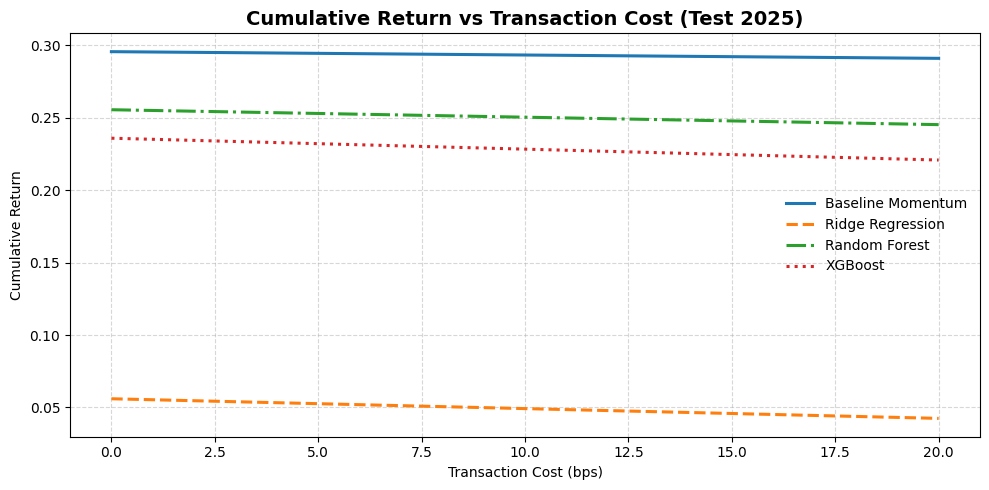

In [6]:
cost_bps = [0, 10, 20]

baseline_cum = [
    base_costs["cost_0bps"]["cumulative_return"],
    base_costs["cost_10bps"]["cumulative_return"],
    base_costs["cost_20bps"]["cumulative_return"],
]

ridge_cum = [
    ridge_costs["cost_0bps"]["cumulative_return"],
    ridge_costs["cost_10bps"]["cumulative_return"],
    ridge_costs["cost_20bps"]["cumulative_return"],
]

rf_cum = [
    rf_costs["cost_0bps"]["cumulative_return"],
    rf_costs["cost_10bps"]["cumulative_return"],
    rf_costs["cost_20bps"]["cumulative_return"],
]

xgb_cum = [
    xgb_costs["cost_0bps"]["cumulative_return"],
    xgb_costs["cost_10bps"]["cumulative_return"],
    xgb_costs["cost_20bps"]["cumulative_return"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_cum, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle=":")
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Cost-adjusted Sharpe comparison

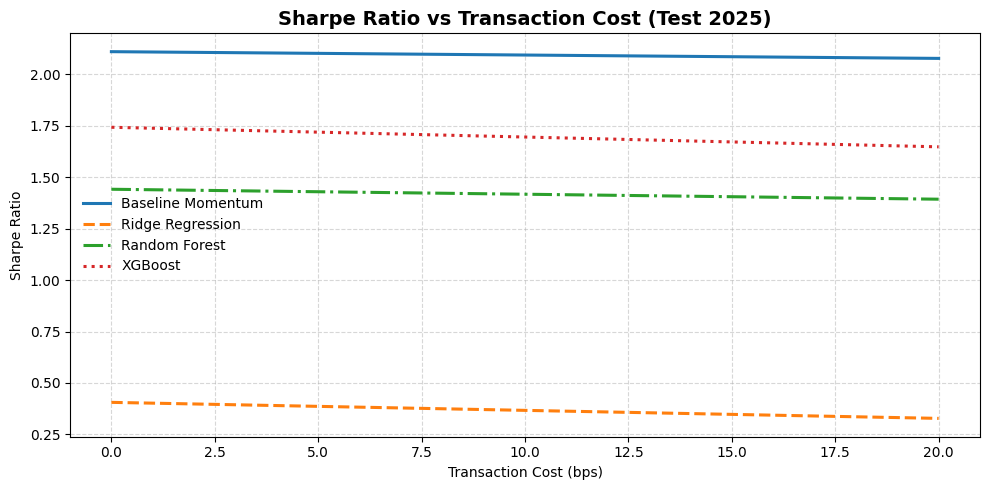

In [7]:
baseline_sharpe = [
    base_costs["cost_0bps"]["sharpe_ratio"],
    base_costs["cost_10bps"]["sharpe_ratio"],
    base_costs["cost_20bps"]["sharpe_ratio"],
]

ridge_sharpe = [
    ridge_costs["cost_0bps"]["sharpe_ratio"],
    ridge_costs["cost_10bps"]["sharpe_ratio"],
    ridge_costs["cost_20bps"]["sharpe_ratio"],
]

rf_sharpe = [
    rf_costs["cost_0bps"]["sharpe_ratio"],
    rf_costs["cost_10bps"]["sharpe_ratio"],
    rf_costs["cost_20bps"]["sharpe_ratio"],
]

xgb_sharpe = [
    xgb_costs["cost_0bps"]["sharpe_ratio"],
    xgb_costs["cost_10bps"]["sharpe_ratio"],
    xgb_costs["cost_20bps"]["sharpe_ratio"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_sharpe, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle=":")
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Compact summary table (Test 2025)

In [8]:
summary_table = pd.DataFrame({
    "Strategy": ["Baseline", "Ridge", "Random Forest", "XGBoost"],
    "Gross_Return_2025": [
        base_test["cumulative_return"],
        ridge_test["cumulative_return"],
        rf_test["cumulative_return"],
        xgb_test["cumulative_return"],
    ],
    "Return_10bps": [
        base_costs["cost_10bps"]["cumulative_return"],
        ridge_costs["cost_10bps"]["cumulative_return"],
        rf_costs["cost_10bps"]["cumulative_return"],
        xgb_costs["cost_10bps"]["cumulative_return"],
    ],
    "Return_20bps": [
        base_costs["cost_20bps"]["cumulative_return"],
        ridge_costs["cost_20bps"]["cumulative_return"],
        rf_costs["cost_20bps"]["cumulative_return"],
        xgb_costs["cost_20bps"]["cumulative_return"],
    ],
    "Sharpe_20bps": [
        base_costs["cost_20bps"]["sharpe_ratio"],
        ridge_costs["cost_20bps"]["sharpe_ratio"],
        rf_costs["cost_20bps"]["sharpe_ratio"],
        xgb_costs["cost_20bps"]["sharpe_ratio"],
    ],
    "Avg_Turnover": [
        base_test["avg_turnover"],
        ridge_test["avg_turnover"],
        rf_test["avg_turnover"],
        xgb_test["avg_turnover"],
    ]
})

display(summary_table.sort_values("Return_20bps", ascending=False))

,Strategy,Gross_Return_2025,Return_10bps,Return_20bps,Sharpe_20bps,Avg_Turnover
0,Baseline,0.295569,0.293265,0.290966,2.076449,0.150000
2,Random Forest,0.255496,0.250342,0.245207,1.392556,0.381818
3,XGBoost,0.235840,0.228286,0.220773,1.646906,0.568182
1,Ridge,0.055996,0.049203,0.042449,0.328015,0.590909


## 7. Save report tables and figures

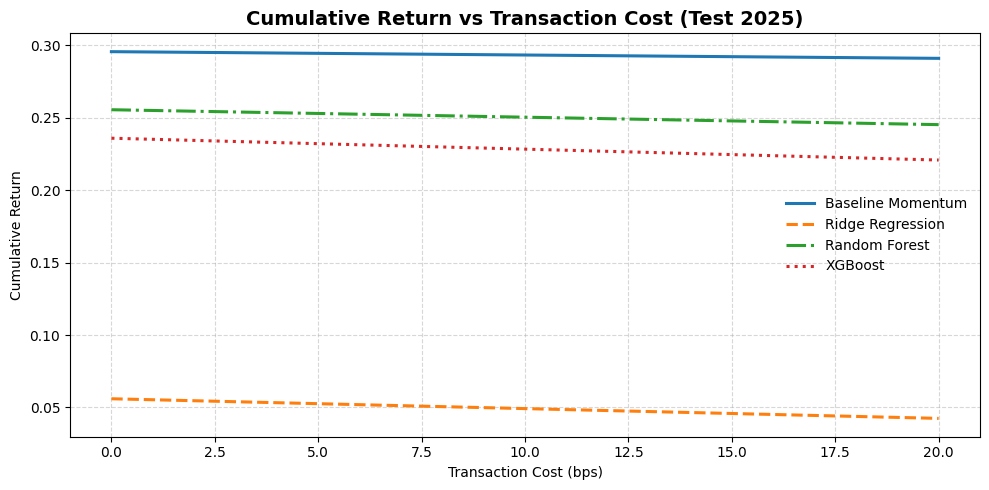

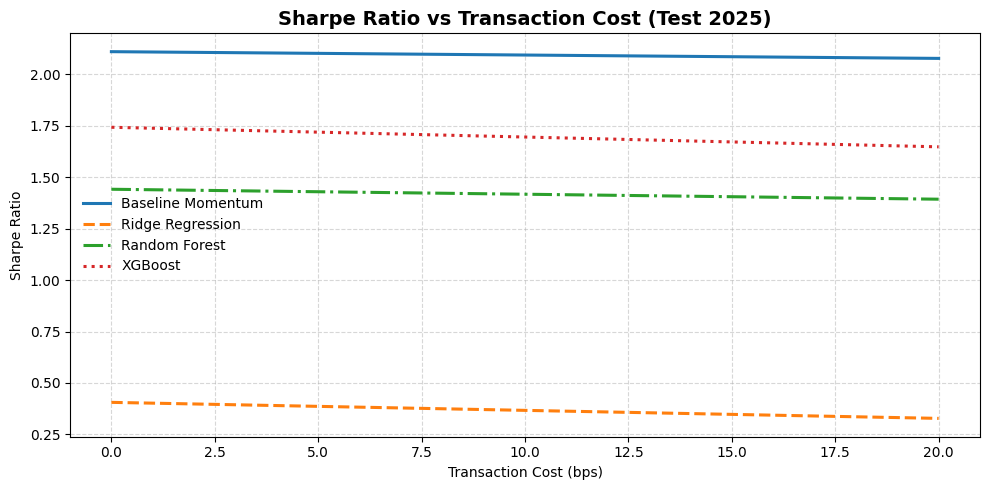

Saved figures and tables to: reports/figures/results_all_models


In [9]:
OUT_DIR = "reports/figures/results_all_models"
os.makedirs(OUT_DIR, exist_ok=True)

gross_table.to_csv(os.path.join(OUT_DIR, "gross_strategy_metrics_test2025.csv"), index=False)
pred_table.to_csv(os.path.join(OUT_DIR, "prediction_metrics_test2025.csv"), index=False)
summary_table.to_csv(os.path.join(OUT_DIR, "summary_table_test2025.csv"), index=False)

# Save cumulative return plot
plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_cum, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle=":")
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cumulative_return_vs_cost_all_models.png"), dpi=300)
plt.show()

# Save Sharpe plot
plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_sharpe, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle=":")
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sharpe_vs_cost_all_models.png"), dpi=300)
plt.show()

print("Saved figures and tables to:", OUT_DIR)

## 8. Final interpretation (report-ready)

Key findings from the 2025 hold-out comparison:

- The **baseline momentum strategy** remained the strongest and most robust overall, especially after transaction costs.
- **Ridge regression** produced the weakest ML performance and deteriorated further once costs were included.
- **Random Forest** offered the best balance among the ML models, with strong ranking performance and lower turnover than Ridge and XGBoost.
- **XGBoost** delivered strong results and clearly outperformed Ridge, but it still did not surpass the baseline in the 2025 hold-out period.
- These results suggest that increasing model complexity can improve stock ranking quality, but practical usefulness depends critically on turnover and cost sensitivity.